In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D

In [3]:
dataset = pd.read_csv('dataset7.csv')

In [4]:
dataset.head()

,timeTotal,timeSpindle,date,idProgP,idProgC,modeCN,idTool,InstTool,ToolWear,Nline,...,FFT_15,FFT_16,FFT_17,FFT_18,FFT_19,FFT_20,FFT_21,FFT_22,FFT_23,FFT_24
0,5560800.0,4105600.0,190310000.0,31,69,2,0,0,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5560800.0,4105600.0,190310000.0,31,69,2,0,0,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5560800.0,4105600.0,190310000.0,31,69,2,0,0,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5560800.0,4105600.0,190310000.0,31,69,2,0,0,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5560800.0,4105600.0,190310000.0,31,69,2,0,0,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
dataset.shape

(862574, 72)

In [6]:
dataset.columns

Index(['timeTotal', 'timeSpindle', 'date', 'idProgP', 'idProgC', 'modeCN',
       'idTool', 'InstTool', 'ToolWear', 'Nline', 'Nbloc', 'Abloc', 'Cbloc',
       'Temp_1', 'Temp_2', 'Temp_3', 'Temp_4', 'Arms_1', 'Arms_2', 'Arms_3',
       'Arms_4', 'Apic_1', 'Apic_2', 'Apic_3', 'Apic_4', 'Vrms_1', 'Vrms_2',
       'Vrms_3', 'Vrms_4', 'Vpic_1', 'Vpic_2', 'Vpic_3', 'Vpic_4', 'PosX',
       'PosY', 'PosZ', 'PosA', 'PosC', 'SpeedX', 'SpeedY', 'SpeedZ', 'SpeedA',
       'SpeedC', 'Vf ', 'N', 'P', '%Vf', '%N', 'FFT_1', 'FFT_2', 'FFT_3',
       'FFT_4', 'FFT_5', 'FFT_6', 'FFT_7', 'FFT_8', 'FFT_9', 'FFT_10',
       'FFT_11', 'FFT_12', 'FFT_13', 'FFT_14', 'FFT_15', 'FFT_16', 'FFT_17',
       'FFT_18', 'FFT_19', 'FFT_20', 'FFT_21', 'FFT_22', 'FFT_23', 'FFT_24'],
      dtype='object')

In [7]:
#dictionnaire des couleurs 
color_dict_cluster={ 1:'r',2:'g' ,3:'b',4:'y',5:'c',6:'m',7:'k',8:'orange',0:'teal'}

1) Data Understanding

The dataset were collected by EmmaTools device on a 5-axes machine-tool of Five Machining in an 
aeronautic company that manufactures structural parts in aluminum alloy. The matrix consists in 72 
variables (columns), measured every tenth of a second (rows), during one day of industrial 
production

In [8]:
data32 = dataset[dataset['idProgP'] == 32]
data32.reset_index(inplace = True)

In [9]:
data32.head()

,index,timeTotal,timeSpindle,date,idProgP,idProgC,modeCN,idTool,InstTool,ToolWear,...,FFT_15,FFT_16,FFT_17,FFT_18,FFT_19,FFT_20,FFT_21,FFT_22,FFT_23,FFT_24
0,206071,5766900.0,4292600.0,191210000.0,32,70,2,0,0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,206072,5766900.0,4292600.0,191210000.0,32,70,2,0,0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,206073,5766900.0,4292600.0,191210000.0,32,70,2,0,0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,206074,5766900.0,4292600.0,191210000.0,32,70,2,0,0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,206075,5766900.0,4292600.0,191210000.0,32,70,2,0,0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


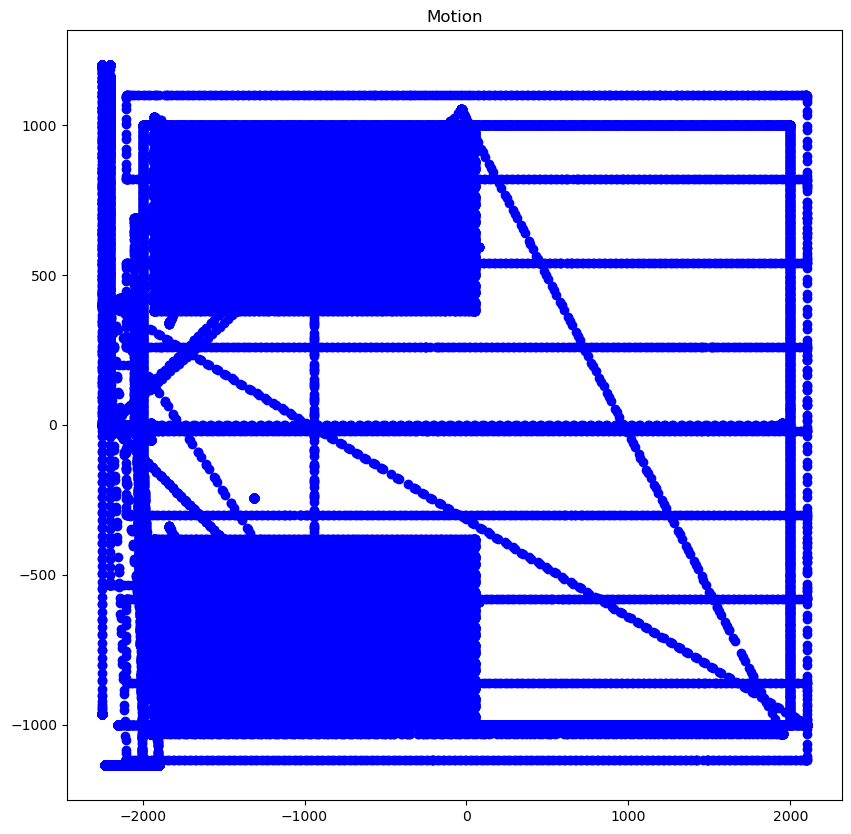

In [10]:
fig = plt.figure(figsize=(10, 10))
plt.scatter(data32['PosX'],data32['PosY'] , c='b')
plt.title('Motion') 
plt.show()

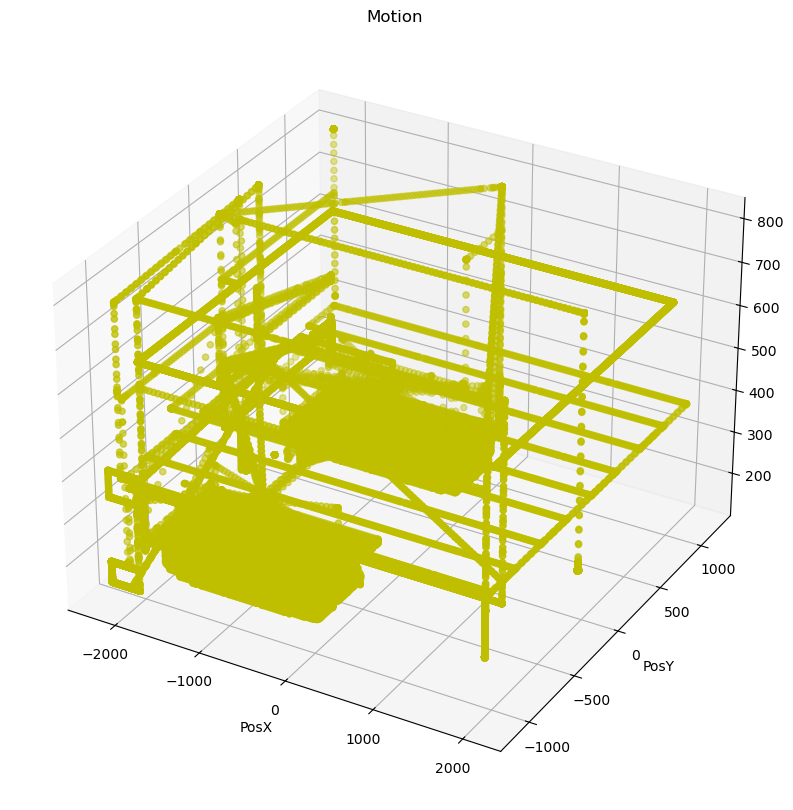

In [11]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection = '3d')
ax.scatter(data32['PosX'],data32['PosY'],data32['PosZ'],c='y')
plt.xlabel('PosX')
plt.ylabel('PosY')
plt.title('Motion')
plt.show()

2. Objective 1: number of parts machined


The objective is to determine how many parts were machined on each pallet, by unsupervised 
machine learning. Clustering will be performed on data set of machine-tool motion.

## KMeans

In [12]:
input = ['PosX','PosY']


#Normalisation des données 

data32.loc[:,input] = ( data32.loc[:,input]-data32.loc[:,input].min() ) / (data32.loc[:,input].max() - data32.loc[:,input].min() ) 

#print(data32[input])

In [13]:
data35 = dataset[dataset['idProgP'] == 35]
data35.reset_index(inplace = True)

Norm32 = ( data32.loc[:,input]-data32.loc[:,input].min() ) / (data32.loc[:,input].max() - data32.loc[:,input].min() ) 

Norm35 = ( data35.loc[:,input]-data35.loc[:,input].min() ) / (data35.loc[:,input].max() - data35.loc[:,input].min() ) 


La méthode elbow nous permet de déterminer combien de clusters nous devons chercher

In [14]:
from sklearn import cluster
from sklearn.cluster import KMeans 
from sklearn.metrics import completeness_score, homogeneity_score
import seaborn as sns

c:\Users\marqu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\marqu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


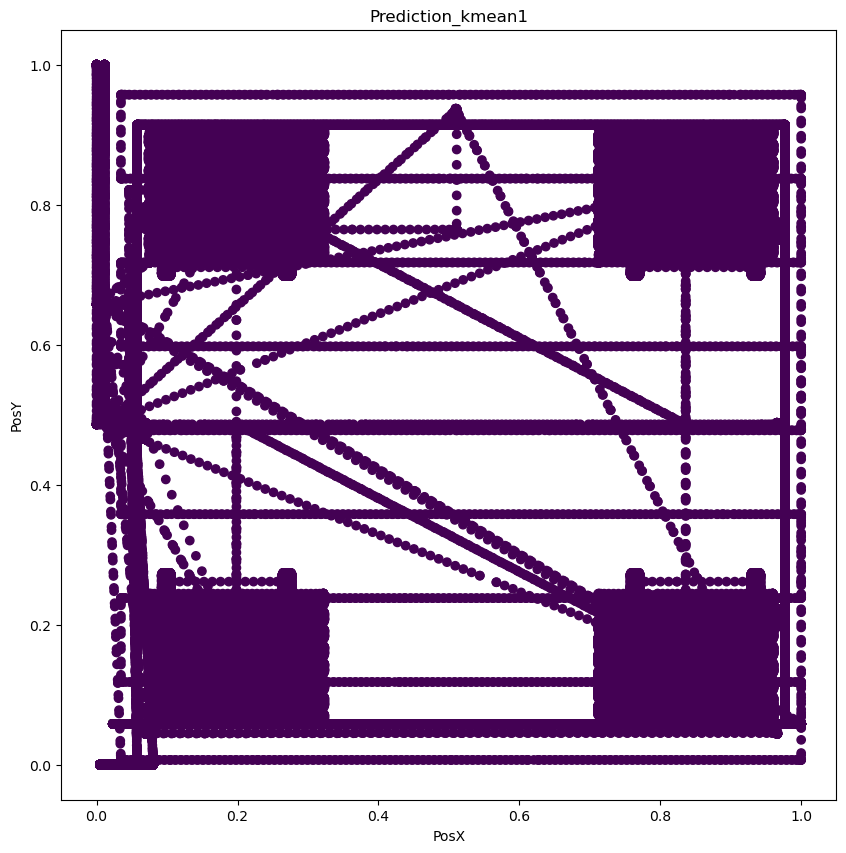

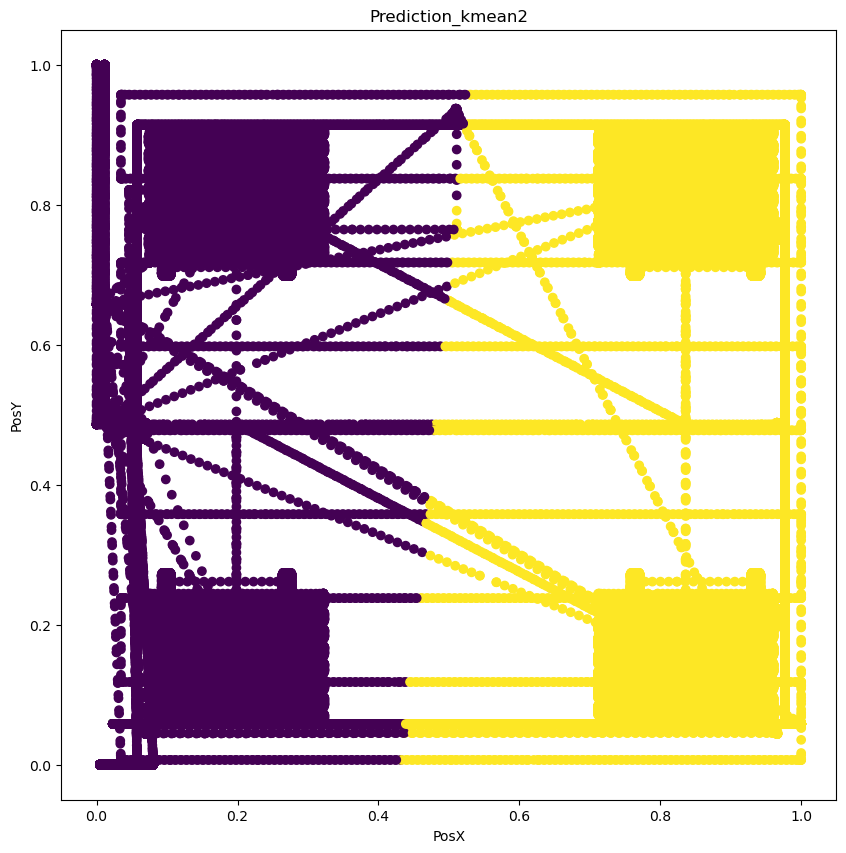

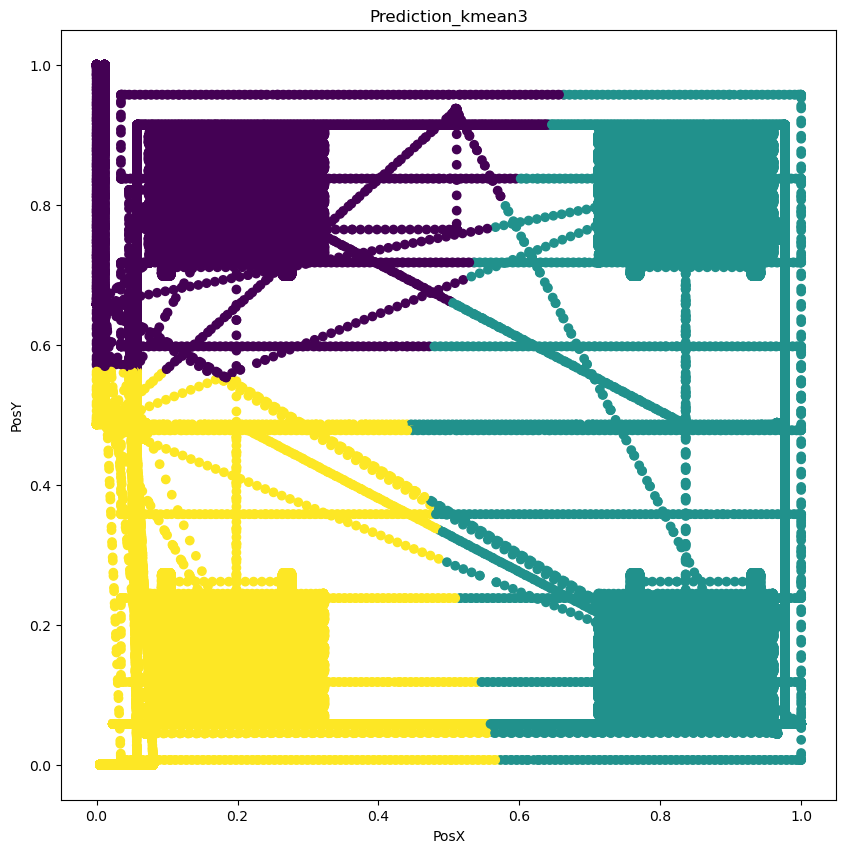

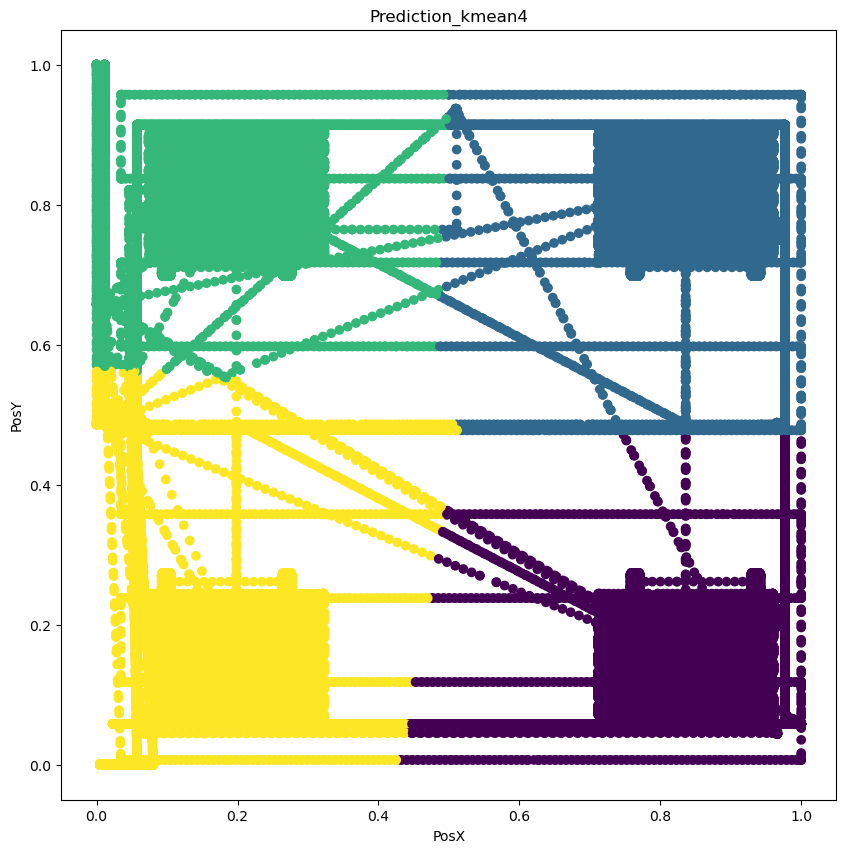

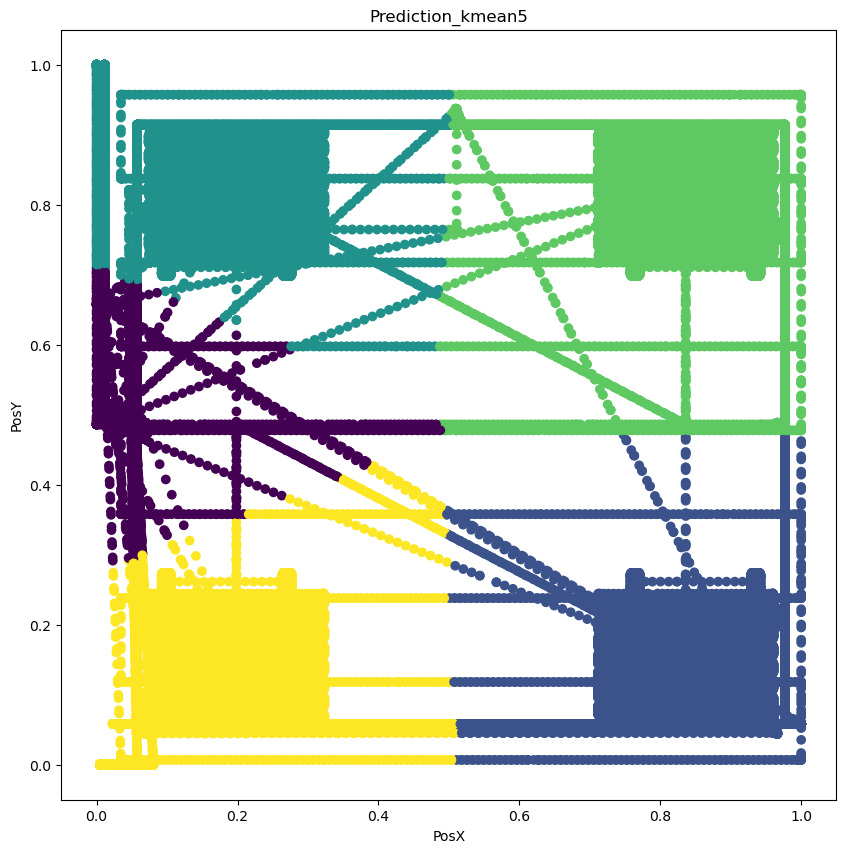

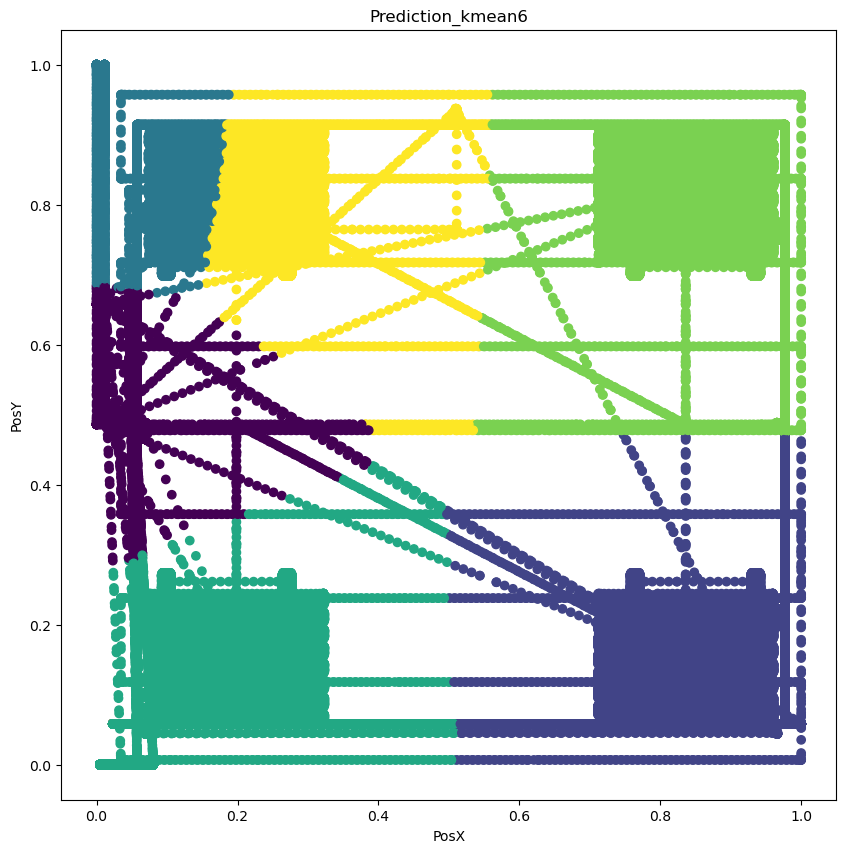

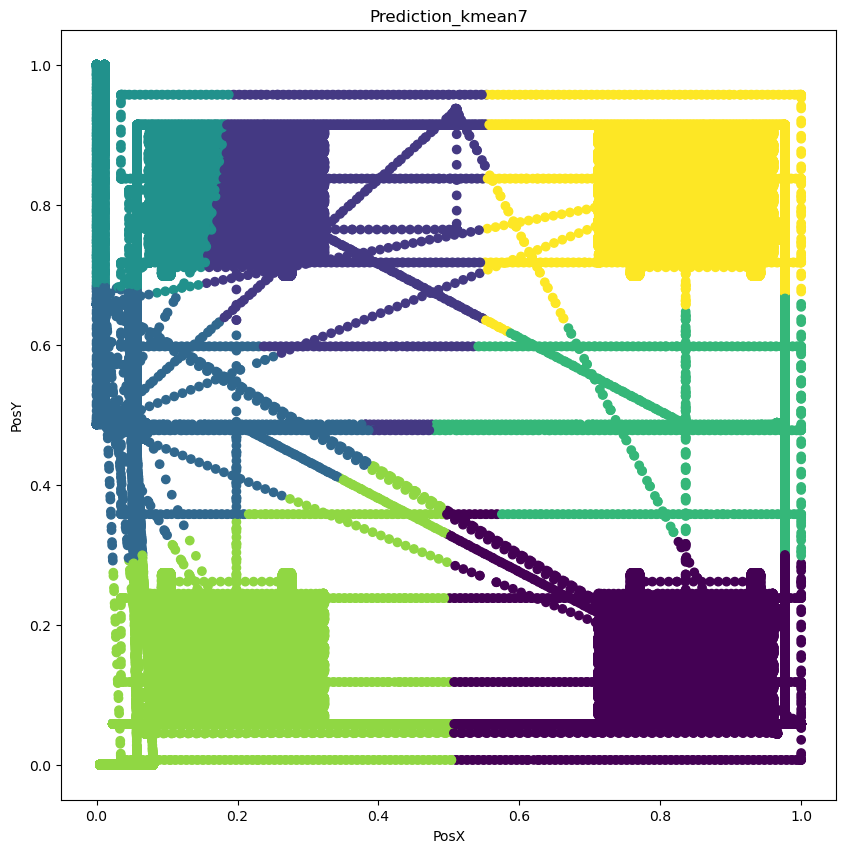

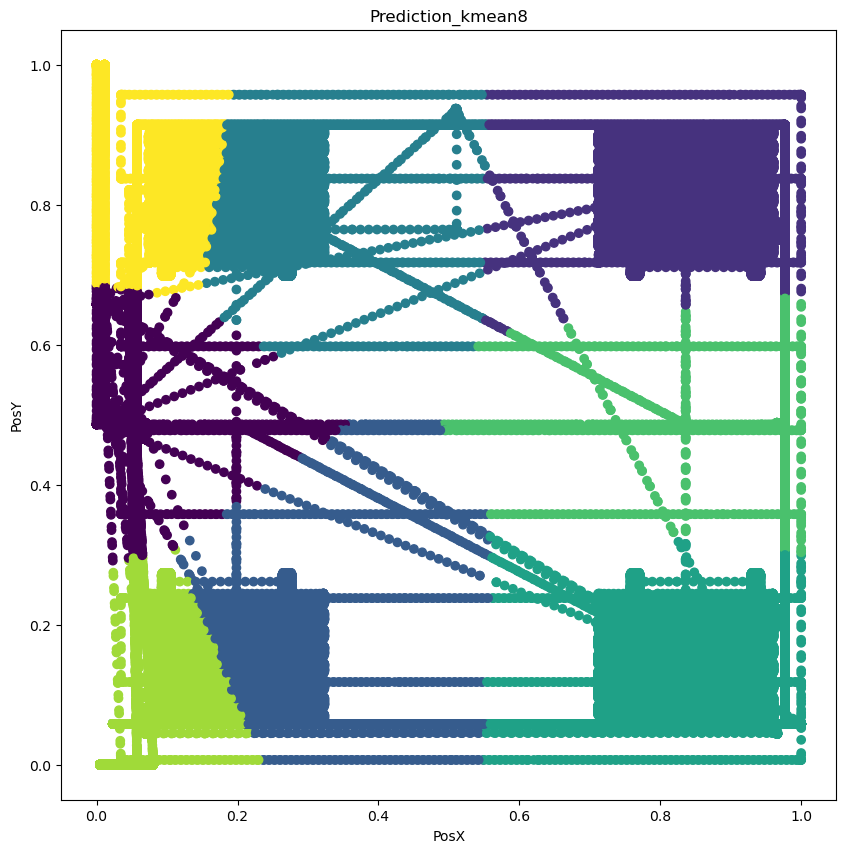

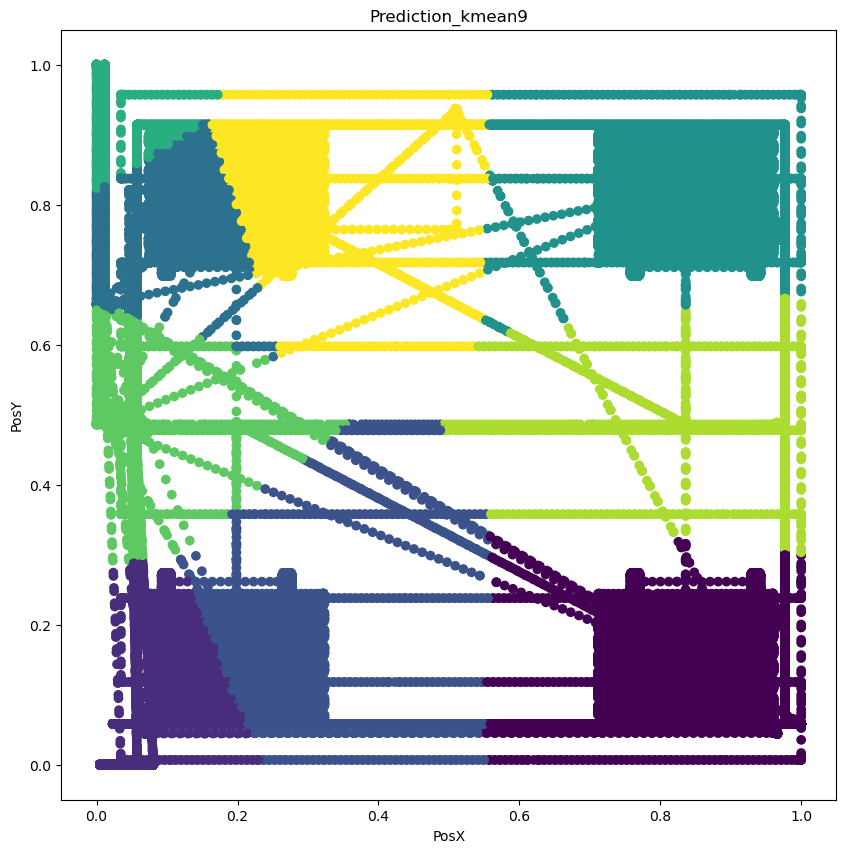

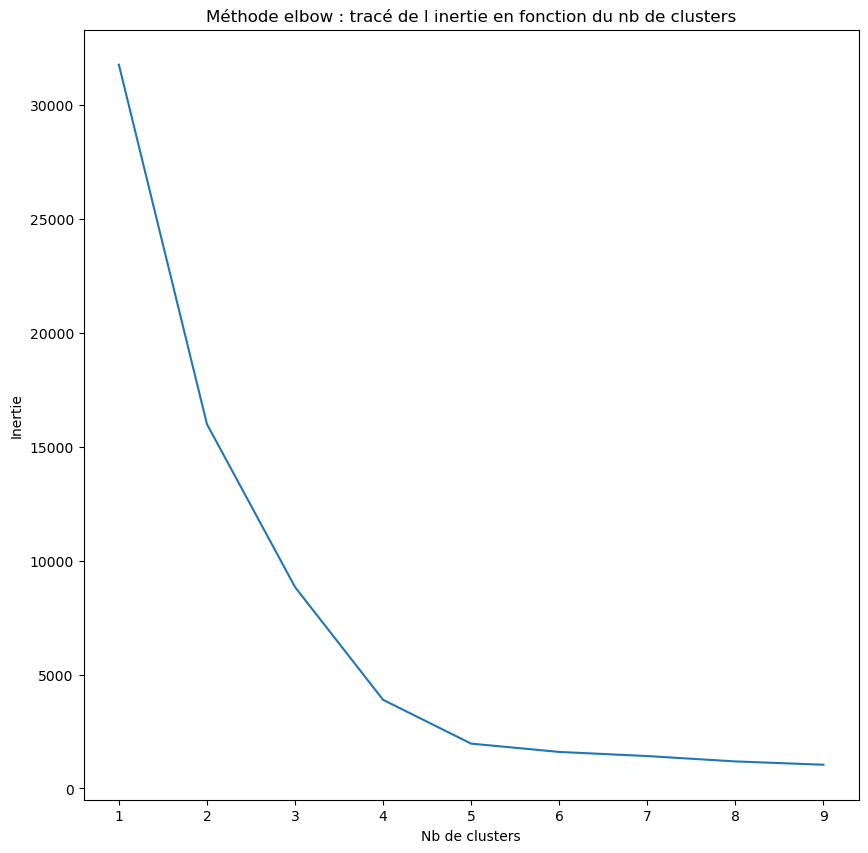

In [15]:
inertia = []

for n in range(1,10) : 
    name='Prediction_kmean'+ str(n)
    kmeans = KMeans(n_clusters = n, max_iter = 50, init = 'random')
    
    kmeans.fit(Norm35[input])
    pred_kmeans = kmeans.predict(Norm35[input])
    
    pred = pd.DataFrame(pred_kmeans)
    pred.columns = [name]
    pred = pd.concat([Norm35,pred],axis = 1)

    inertia_n = kmeans.inertia_
    inertia.append(inertia_n)

        
    fig = plt.figure(figsize = (10,10))
    plt.scatter(pred['PosX'],pred['PosY'], c = pred[name], cmap ='viridis')
    plt.xlabel('PosX')
    plt.ylabel('PosY')
    plt.title(name)
    #plt.colorbar(scatter, label='Cluster')
    plt.show()

fig = plt.figure(figsize = (10,10))
plt.plot(range(1,10),inertia)
plt.title('Méthode elbow : tracé de l inertie en fonction du nb de clusters')
plt.xlabel('Nb de clusters')
plt.ylabel('Inertie')
plt.show()



N_clusters = 4 semble être un choix approprié

## GaussianMixture

In [16]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from matplotlib.patches import Ellipse


In [17]:
def draw_ellipse(position, covariance, ax = None , **kwargs) : 

    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Draw the Ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(xy = position, width = nsig * width, height = nsig * height, angle = angle, **kwargs))


def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X[input]).predict(X[input])
    if label:
        ax.scatter(X['PosX'], X['PosY'], c=labels, s=40, cmap='viridis', zorder=2)
    else:
        ax.scatter(X['PosX'], X['PosY'], s=40, zorder=2)
    
    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, alpha=w * w_factor)
    plt.title("GMM with %d components"%len(gmm.means_), fontsize=(20))
    plt.xlabel("U.A.")
    plt.ylabel("U.A.")

In [18]:
#GMM = GaussianMixture(3)
#plot_gmm(GMM,Norm32)

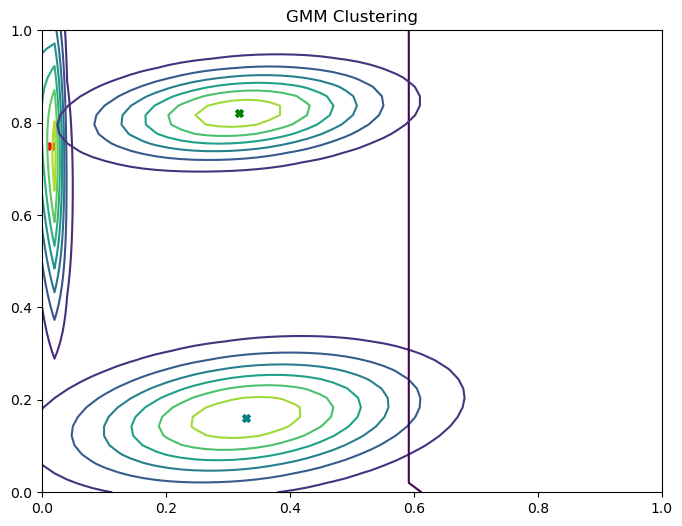

In [19]:
from scipy.stats import multivariate_normal

name='GMM_'+str(3) 

GMM = GaussianMixture(n_components=3)
GMM.fit(Norm32[input])
labels = GMM.predict(Norm32[input])

pred = pd.DataFrame(labels)
pred.columns = [name]
Norm32 = pd.concat([Norm32,pred],axis=1)

means = GMM.means_
cov = GMM.covariances_
weights = GMM.weights_

# Plot the data and the initial model

x = np.linspace(0, 1)
y = np.linspace(0, 1)
X,Y = np.meshgrid(x,y)
# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

fig, ax = plt.subplots(figsize=(8, 6)
                      )
for i,(mean,cova) in enumerate(zip(means,cov)) :
    rv = multivariate_normal(mean,cova)
    plt.contour(x,y,rv.pdf(pos))
    plt.scatter(mean[0],mean[1],marker='X',c=color_dict_cluster[i],s=30)
plt.title('GMM Clustering')
plt.show()

In [20]:
https://github.com/vlavorini/ClusterCardinality/blob/master/Cluster%20Cardinality.ipynb

https://towardsdatascience.com/gaussian-mixture-model-clusterization-how-to-select-the-number-of-components-clusters-553bef45f6e4


SyntaxError: invalid decimal literal (2777859360.py, line 1)

BIC Score

In [23]:
def SelBest(arr:list, X:int)->list:
    '''
    returns the set of X configurations with shorter distance
    '''
    arr_np = np.array(arr)
    dx=np.argsort(arr)[:X]
    return arr[dx]

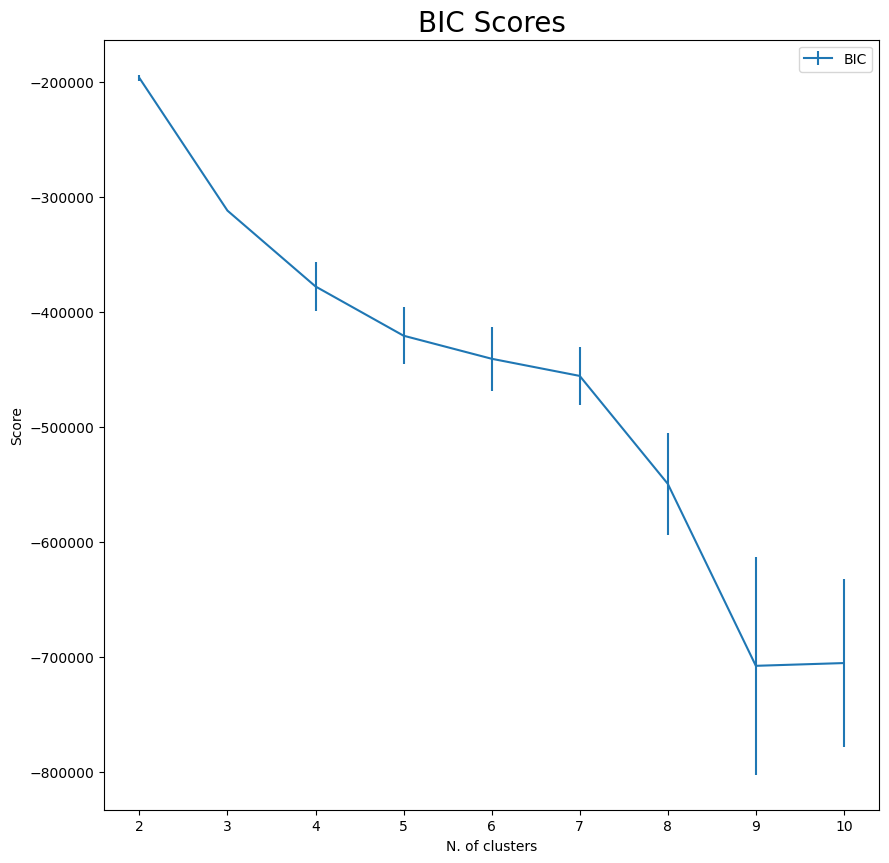

In [24]:
from sklearn.metrics import silhouette_score

n_components = range(2,11,1)
BIC = []
BIC_err = []
iterations = 20

for n in n_components : 
    tmp_BIC = []
    for _ in range(iterations) :
        GMM = GaussianMixture(n_components=n)
        GMM.fit(Norm32[input])
        tmp_BIC.append(GMM.bic(Norm32[input]))
        
    val=np.mean(SelBest(np.array(tmp_BIC), int(iterations/5)))
    err=np.std(tmp_BIC)
    BIC.append(val)
    BIC_err.append(err)

fig = plt.figure(figsize = (10,10))
plt.errorbar(n_components,BIC, yerr=BIC_err, label='BIC')
plt.title("BIC Scores", fontsize=20)
plt.xticks(n_components)
plt.xlabel("N. of clusters")
plt.ylabel("Score")
plt.legend()
plt.show()


In [25]:
plt.errorbar(n_clusters, np.gradient(BIC), yerr=BIC_err, label='BIC')
plt.title("Gradient of BIC Scores", fontsize=20)
plt.xticks(n_components)
plt.xlabel("N. of clusters")
plt.ylabel("grad(BIC)")
plt.legend()
plt.show()

NameError: name 'n_clusters' is not defined

In [ ]:
Train-Test calcul de distance

In [ ]:
def gmm_js(gmm_p, gmm_q, n_samples=10**5):
    X = gmm_p.sample(n_samples)[0]
    log_p_X = gmm_p.score_samples(X)
    log_q_X = gmm_q.score_samples(X)
    log_mix_X = np.logaddexp(log_p_X, log_q_X)

    Y = gmm_q.sample(n_samples)[0]
    log_p_Y = gmm_p.score_samples(Y)
    log_q_Y = gmm_q.score_samples(Y)
    log_mix_Y = np.logaddexp(log_p_Y, log_q_Y)

    return np.sqrt((log_p_X.mean() - (log_mix_X.mean() - np.log(2))
            + log_q_Y.mean() - (log_mix_Y.mean() - np.log(2))) / 2)

In [ ]:
n_clusters=np.arange(2, 20)
iterations=20
results=[]
res_sigs=[]
for n in n_clusters:
    dist=[]
    
    for _ in range(iterations):
        train, test=train_test_split(embeddings, test_size=0.5)
        
        gmm_train=GMM(n, n_init=2).fit(train) 
        gmm_test=GMM(n, n_init=2).fit(test) 
        dist.append(gmm_js(gmm_train, gmm_test))
    selec=SelBest(np.array(dist), int(iterations/5))
    result=np.mean(selec)
    res_sig=np.std(selec)
    results.append(result)
    res_sigs.append(res_sig)

In [ ]:
plt.errorbar(n_clusters, results, yerr=res_sigs)
plt.title("Distance between Train and Test GMMs", fontsize=20)
plt.xticks(n_clusters)
plt.xlabel("N. of clusters")
plt.ylabel("Distance")
plt.legend()
plt.show()
